# Line RT — High-Level Interface with Callable Fields

This notebook uses the **convenience class `linert.LineRT`** with callable
functions for scattering density and temperature (instead of pre-computed
flat arrays).  The CO J=1→0 transition is selected **explicitly by level
numbers** (`upper=1, lower=0`).

### Key advantages of the high-level API

1. No file paths or par overrides to manage — LineRT handles everything.
2. Callable functions `(X,Y,Z) → array` are evaluated automatically at
   each cell centre during field initialisation.
3. Transition selection is explicit: `upper=1, lower=0`.
4. Automatic population cycling with `result = rt.run(n_cycles=3)`.

## 0. Imports & Constants

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.expanduser('~/scratch/line_rt'))
sys.path.insert(0, os.path.expanduser(
    '~/Seafile/seafile_sync/code/line_rt_pipeline'))

import numpy as np
import matplotlib.pyplot as plt

from linert import LineRT, SlabSource, PointSource, Result
from molecular.lamda_format import load_species_transition

AU = 1.49598e13
Lsun = 3.828e33

print('Imports OK')

Imports OK


## 1. Callable Field Functions

These functions receive coordinate arrays `(X, Y, Z)` in AU and must
return arrays of the same shape.  **Replace the bodies** with any desired
spatial profile — LineRT will evaluate them at every cell centre.

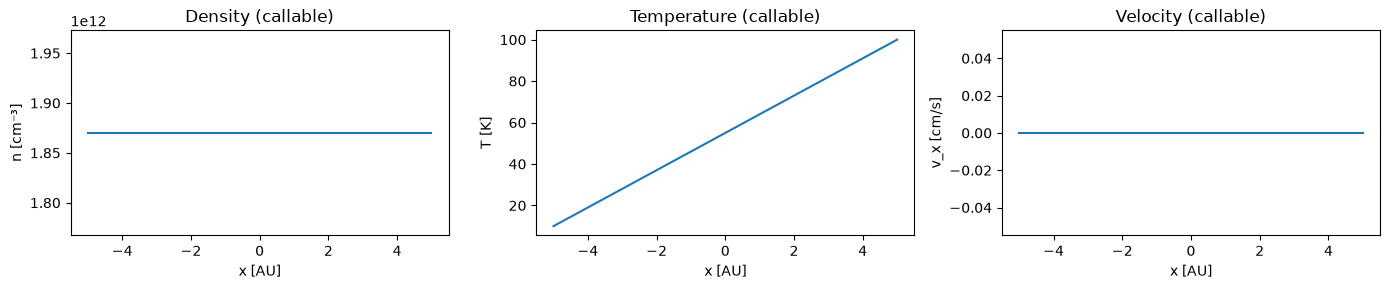

In [2]:
def n_total_callable(X, Y, Z):
    """Scattering particle density [cm⁻³].
    
    Alternatives:
        return 1e4 * np.exp(-0.5 * (X / 3.)**2)   # Gaussian profile
        return 1e4 * (np.abs(X) / 5. + 0.1)**-1.5 # power-law
    """
    return np.full_like(X, 1.87e12, dtype=np.float64)


def velocity_callable(X, Y, Z):
    """Bulk velocity [cm/s] — static slab."""
    return (np.zeros_like(X), np.zeros_like(X), np.zeros_like(X))


def temperature_callable(X, Y, Z):
    """Gas temperature [K].
    
    Linear gradient from 10 K (left) → 100 K (right).
    Constant example:  return np.full_like(X, 50.0)
    """
    return 10.0 + 90.0 * (X + 5.0) / 10.0


# Quick visualisation of the callable profiles
x_test = np.linspace(-5, 5, 64)
y_test = np.zeros(64)
z_test = np.zeros(64)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(x_test, n_total_callable(x_test, y_test, z_test))
axes[0].set(xlabel='x [AU]', ylabel='n [cm⁻³]', title='Density (callable)')
axes[1].plot(x_test, temperature_callable(x_test, y_test, z_test))
axes[1].set(xlabel='x [AU]', ylabel='T [K]', title='Temperature (callable)')
vx, vy, vz = velocity_callable(x_test, y_test, z_test)
axes[2].plot(x_test, vx)
axes[2].set(xlabel='x [AU]', ylabel='v_x [cm/s]', title='Velocity (callable)')
fig.tight_layout()
plt.show()

## 2. Load CO and Select Transition

The transition is **explicitly identified** as `CO J=1→0` by specifying
`upper=1, lower=0`.  Other valid selectors:
- `freq_GHz=115.271202` — by rest frequency
- `wavelength_um=2600.76` — by wavelength
- `E_u_K=3.87` — by upper-level energy

In [3]:
lamda_path = os.path.expanduser(
    '~/Seafile/seafile_sync/code/line_rt_pipeline/molecular/embedded/co.dat')
co, tr = load_species_transition(lamda_path, upper=1, lower=0)

print(f'Species: CO  ({co.n_levels} levels, {co.n_transitions} transitions)')
print(f'Transition:  J={tr.upper} → J={tr.lower}  (explicit level selection)')
print(f'  A_ul  = {tr.A_ul:.2e} s⁻¹')
print(f'  ν₀    = {tr.freq_GHz:.2f} GHz')
print(f'  λ     = {tr.wavelength_um:.1f} µm')
print(f'  E_u/K = {tr.E_u_K:.2f} K')

Species: CO  (10 levels, 9 transitions)
Transition:  J=1 → J=0  (explicit level selection)
  A_ul  = 7.20e-08 s⁻¹
  ν₀    = 115.27 GHz
  λ     = 2600.8 µm
  E_u/K = 3.85 K


## 3. Configure and Run LineRT

All physics is specified in the constructor.  LineRT handles file I/O,
Kratos execution, and population cycling automatically.

Key parameters:
- `species=co, n_total=n_total_callable` → Mode 2 (species-based opacity)
- `transition=tr` → CO J=1→0
- `temperature=temperature_callable` → spatial gradient
- `mol_mass=28.0` → thermal broadening for CO

In [4]:
rt = LineRT(
    source=SlabSource(x0=-5., n_photon=20000, b_sca=1e5),

    x_min=(-5, 0, 0),
    x_max=(5, 0.2, 0.2),
    n_cell=(64, 2, 2),

    species=co,
    n_total=n_total_callable,
    transition=tr,
    temperature=temperature_callable,
    velocity=velocity_callable,

    n_photon=20000,
    n_step=20000,
    n_scat=200000,
    ph_mode=1,                 # CFR
    n_cycles=3,
    mol_mass=28.0,
    n_emission_max=5,
    work_dir='/tmp/linert_hl_callables',
)

print(f'Mesh: {rt.n_cell} cells, total = {rt.n_tot}')
print(f'Mol mass: {rt.mol_mass} g/mol')
print(f'Transition idx: {rt.transition_idx}')

Mesh: (64, 2, 2) cells, total = 256
Mol mass: 28.0 g/mol
Transition idx: 0


/home/lilew/scratch/line_rt/linert.py:547: UserWarning: No collider density specified; collisional (de-)excitation will be ignored.
  warnings.warn("No collider density specified; "


## 4. Run Iteration

Each cycle:
1. Evaluates callable fields at cell centres
2. Runs Kratos with overlap-weighted excitation
3. Reads back `excitation_flux`
4. Updates level populations (LTE → NLTE convergence)
5. Generates emission photons from upper-level populations

In [5]:
def on_cycle(cycle, cr):
    pop_str = ''
    if cr.populations is not None:
        n0 = cr.populations.get('n0', [0])
        pop_str = f'  pop(n0)=[{np.min(n0):.2e}, {np.max(n0):.2e}]'
    print(f'  Cycle {cycle}:  '
          f'exc_flux=[{cr.excitation_flux.min():.2e}, {cr.excitation_flux.max():.2e}],  '
          f'flx=[{cr.flx.min():.2e}, {cr.flx.max():.2e}],  '
          f'exc=[{cr.exc_rate.min():.2e}, {cr.exc_rate.max():.2e}],  '
          f'n_esc={len(cr.photons)},  '
          f't={cr.elapsed:.1f}s'
          f'{pop_str}')

result = rt.run(callback=on_cycle)
print(f'\n{result}')

=== Cycle 0 / 3 ===
Wrote fields: /tmp/linert_hl_callables/fields_cycle0.bin
Wrote photons: /tmp/linert_hl_callables/photons_cycle0.bin (20000 photons, 11 cols)
  exc_flux_max=7.8938e+01, flx_max=5.6146e+01, exc_max=0.0000e+00, n_esc=20000, t=0.9s
  Cycle 0:  exc_flux=[5.34e-28, 7.89e+01],  flx=[1.05e-28, 5.61e+01],  exc=[0.00e+00, 0.00e+00],  n_esc=20000,  t=0.9s  pop(n0)=[0.00e+00, 1.87e+12]
=== Cycle 1 / 3 ===
Wrote fields: /tmp/linert_hl_callables/fields_cycle1.bin
Wrote photons: /tmp/linert_hl_callables/photons_cycle1.bin (21270 photons, 11 cols)
  exc_flux_max=9.2746e+01, flx_max=5.6515e+01, exc_max=0.0000e+00, n_esc=21270, t=0.7s
  Cycle 1:  exc_flux=[1.72e-12, 9.27e+01],  flx=[3.96e-13, 5.65e+01],  exc=[0.00e+00, 0.00e+00],  n_esc=21270,  t=0.7s  pop(n0)=[0.00e+00, 1.87e+12]
=== Cycle 2 / 3 ===
Wrote fields: /tmp/linert_hl_callables/fields_cycle2.bin
Wrote photons: /tmp/linert_hl_callables/photons_cycle2.bin (20010 photons, 11 cols)
  exc_flux_max=9.2085e+01, flx_max=5.7018e+01

## 5. Results — Spectrum & Flux Maps

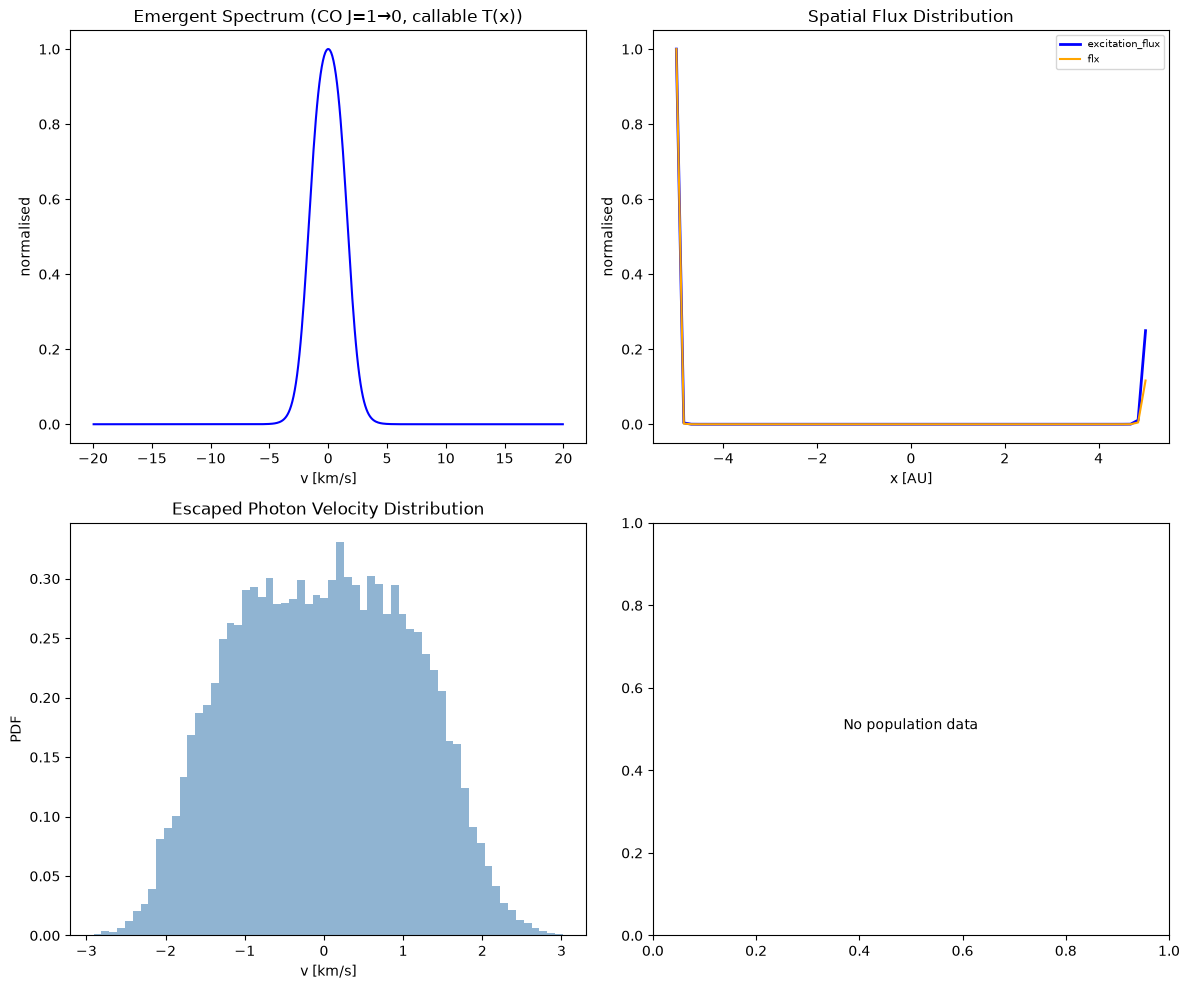

In [6]:
cr = result.cycles[-1]
esc = cr.photons

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 5a. Emergent spectrum from escaped photons
spec = esc.synthesize_spectrum(v_min=-2e6, v_max=2e6, n_bins=400)
v_kms = spec['v_mid'] * 1e-5
flux = spec['spectrum']
axes[0, 0].plot(v_kms, flux / flux.max(), 'b-', lw=1.5)
axes[0, 0].set(xlabel='v [km/s]', ylabel='normalised')
axes[0, 0].set_title('Emergent Spectrum (CO J=1→0, callable T(x))')

# 5b. Spatial flux profiles
nxc = result.n_cell[0]
x_cell = np.linspace(-5, 5, nxc)
exc_x = cr.excitation_flux[:nxc]
flx_x = cr.flx[:nxc]
exc_r = exc_x / exc_x.max()
flx_r = flx_x / flx_x.max()
axes[0, 1].plot(x_cell, exc_r, 'b-', lw=2, label='excitation_flux')
axes[0, 1].plot(x_cell, flx_r, 'orange', lw=1.5, label='flx')
axes[0, 1].set(xlabel='x [AU]', ylabel='normalised')
axes[0, 1].legend(fontsize=7)
axes[0, 1].set_title('Spatial Flux Distribution')

# 5c. Escaped photon velocities
axes[1, 0].hist(esc.velocity * 1e-5, bins=60, density=True,
                alpha=0.6, color='steelblue')
axes[1, 0].set(xlabel='v [km/s]', ylabel='PDF')
axes[1, 0].set_title('Escaped Photon Velocity Distribution')

# 5d. Population fraction
if cr.populations is not None:
    n_ground = cr.populations.get('n0', np.zeros(nxc))[:nxc]
    n_exc = cr.populations.get('n1', np.zeros(nxc))[:nxc]
    frac = n_exc / (n_ground + n_exc + 1e-30)
    axes[1, 1].plot(x_cell, frac, 'r-', lw=2)
    axes[1, 1].set(xlabel='x [AU]', ylabel='n_exc / (n_ground + n_exc)')
    axes[1, 1].set_title('Excited Fraction (CO J=1→0)')
    axes[1, 1].set_yscale('log')
else:
    axes[1, 1].text(0.5, 0.5, 'No population data',
                   transform=axes[1, 1].transAxes, ha='center')

fig.tight_layout()
plt.show()

## 6. How to Customise

### Change the density profile
```python
def n_total_callable(X, Y, Z):
    return 1e4 * np.exp(-0.5 * (X / 3.)**2)  # Gaussian slab
```

### Change the temperature profile
```python
def temperature_callable(X, Y, Z):
    return 20. + 80. * np.exp(-0.5 * X**2)  # hot core
```

### Use a different CO transition
```python
co, tr = load_species_transition(path, upper=2, lower=1)  # CO J=2→1
```

### Point source instead of slab
```python
from linert import PointSource
source = PointSource(position=(0, 0, 0), n_photon=50000, b_sca=1e5)
# ... use in LineRT(source=source, ...)
```